# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (예: `rainy + night + city street` 인 이미지).
3. 모든 백본에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 학습 노트북이 아니라 분석 노트북이지만, wandb 가 활성화되어 있으면 confusion matrix 이미지·Grad-CAM 패널·FPS 표를 같은 프로젝트의 별도 Run 으로 업로드합니다.

In [1]:
import os
import sys

repo_url  = "https://github.com/Seongha-parkk/2026-HYU-AUE8088-PA2.git"
repo_name = "2026-HYU-AUE8088-PA2"

if not os.path.exists(f"/content/{repo_name}"):
    !git clone {repo_url}
else:
    !git -C /content/{repo_name} pull

%cd /content/{repo_name}

%load_ext autoreload
%autoreload 2

!pip install -q -r requirements.txt

Cloning into '2026-HYU-AUE8088-PA2'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 172 (delta 97), reused 122 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 989.42 KiB | 30.92 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/2026-HYU-AUE8088-PA2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 60.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━

In [2]:
from google.colab import drive
import os

drive.mount('/drive')

DRIVE_CKPT = "/drive/MyDrive/aue8088-pa2/checkpoints"
os.makedirs(DRIVE_CKPT, exist_ok=True)

LOCAL_CKPT = os.path.abspath("../checkpoints")
if os.path.islink(LOCAL_CKPT):
    print(f"symlink 이미 존재: {LOCAL_CKPT} → {os.readlink(LOCAL_CKPT)}")
elif os.path.isdir(LOCAL_CKPT):
    import shutil
    for f in os.listdir(LOCAL_CKPT):
        shutil.move(os.path.join(LOCAL_CKPT, f), DRIVE_CKPT)
    shutil.rmtree(LOCAL_CKPT)
    os.symlink(DRIVE_CKPT, LOCAL_CKPT)
    print(f"기존 파일 Drive 이전 후 symlink 생성: {LOCAL_CKPT} → {DRIVE_CKPT}")
else:
    os.symlink(DRIVE_CKPT, LOCAL_CKPT)
    print(f"symlink 생성: {LOCAL_CKPT} → {DRIVE_CKPT}")

Mounted at /drive
symlink 생성: /content/checkpoints → /drive/MyDrive/aue8088-pa2/checkpoints


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, average_macro_f1, CLASS_NAMES
from src.utils.efficiency import measure_fps
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.xai.gradcam import GradCAM
from src.models.resnet import resnet18, resnet50
from src.models.vgg import VGG16
from src.models.vit import vit_small_patch16_224
from src.models.swin import SwinTiny

SEED = 42   # 전체 실험 고정 시드 (torch / numpy / random / cudnn.deterministic)
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  SEED={SEED}")

In [4]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
logger = WandbLogger(project=WANDB_PROJECT, run_name="level4-analysis", tags=["level4", "analysis"])

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: qkrtjdgk16 (qkrtjdgk16-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [5]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."
DATA_ROOT  = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

val_ds     = BDDAttrDataset(DATA_ROOT, "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

# Best 모델: Level3 ViT-S/16 (IR sampler + FocalLoss + RandAugment + CutMix)
BEST_CKPT = "../checkpoints/level3_ir-focal+ir-sampler+randaug+cutmix.pth"
model = vit_small_patch16_224().to(device)
ckpt  = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"best 모델 로드 완료 → {BEST_CKPT}")

데이터셋 zip 다운로드 중...


Downloading...
From (original): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK
From (redirected): https://drive.google.com/uc?id=1L7YC70QlO87aIbE5lbtQ94HUINJijBKK&confirm=t&uuid=433f91ff-db5f-4b3e-8cc4-1b0fff25258c
To: /content/aue8088_pa2_data.zip
100%|██████████| 243M/243M [00:05<00:00, 47.2MB/s] 


압축 해제 중...
완료 → ../data/set_a
best 모델 로드 완료 → ../checkpoints/level3_ir-focal+ir-sampler+randaug+cutmix.pth


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

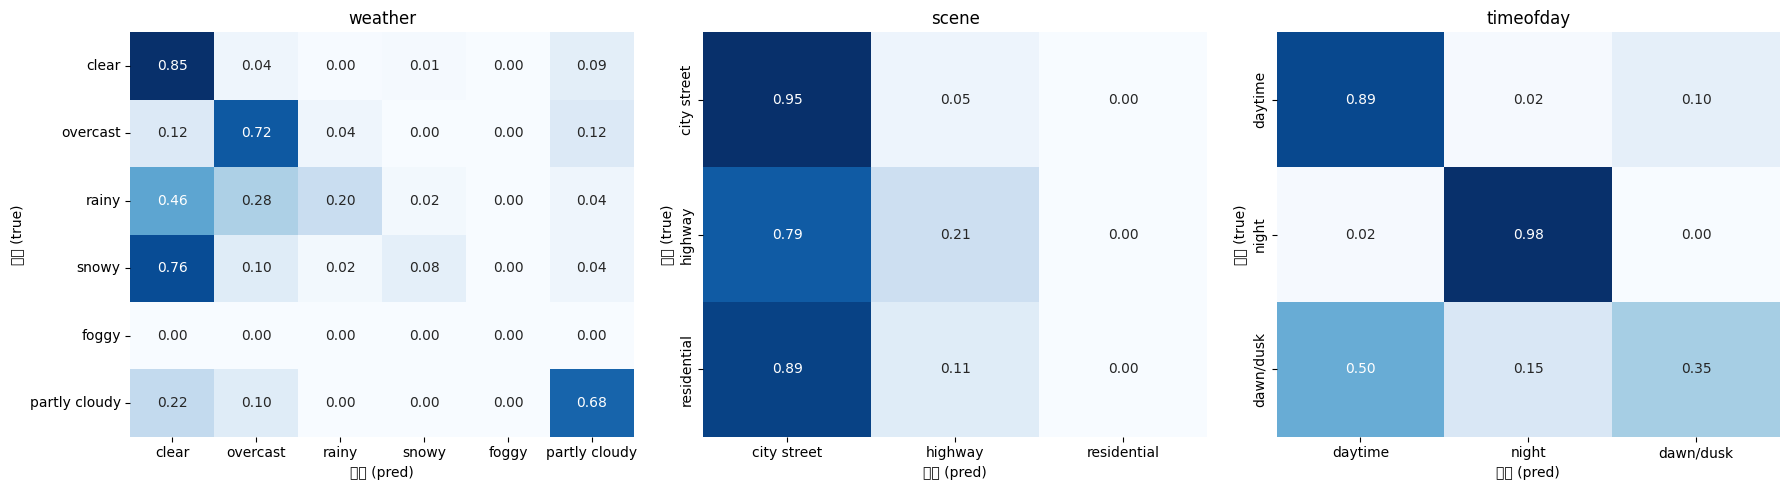

In [6]:
# 속성별 정규화 Confusion Matrix 생성 및 시각화
preds, probs, targets, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(preds, targets, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.tight_layout()
logger.log_image("analysis/confusion_matrices", fig)

# 속성별 개별 confusion matrix 도 분리해서 업로드
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"analysis/cm_{a}", cms[a], CLASS_NAMES[a])

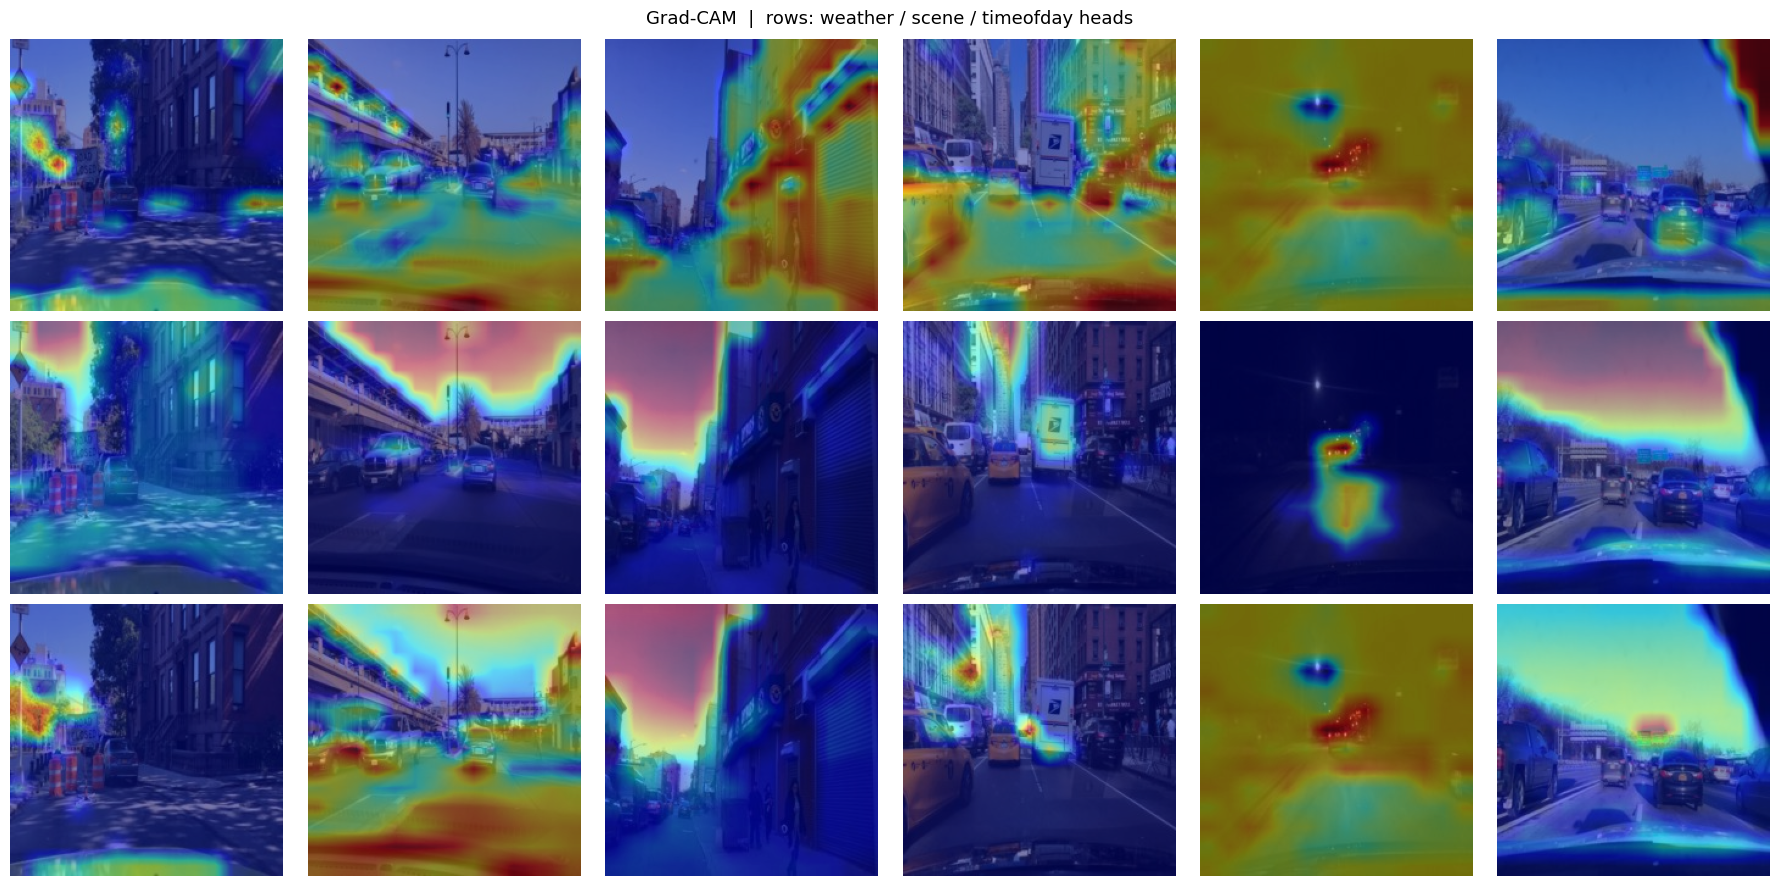

In [7]:
# ViT-S/16 Grad-CAM
# patch_embed.proj = Conv2d(3, 384, 16, 16) → 출력 (B, 384, 14, 14): 4D feature map
target_layer = model.patch_embed.proj
gc = GradCAM(model, target_layer)

batch = next(iter(val_loader))
x = batch["image"][:6].to(device)  # 샘플 이미지 6장

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for row, attr in enumerate(ATTRIBUTES):
    cam = gc(x, lambda out, a=attr: out[a].max(dim=-1).values.sum())
    for col in range(6):
        img = x[col].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, col].imshow(img)
        axes[row, col].imshow(cam[col].cpu().numpy(), cmap="jet", alpha=0.45)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(attr, fontsize=14)
fig.suptitle("Grad-CAM  |  rows: weather / scene / timeofday heads", fontsize=13)
fig.tight_layout()
logger.log_image("analysis/gradcam_panel", fig)

VGG-16        FPS=  110.3  Avg-MF1=0.5570
ResNet-18     FPS=  346.5  Avg-MF1=0.6437
ResNet-50     FPS=  109.4  Avg-MF1=0.6338
ViT-S/16      FPS=  106.0  Avg-MF1=0.4958
Swin-Tiny     FPS=   78.8  Avg-MF1=0.5350


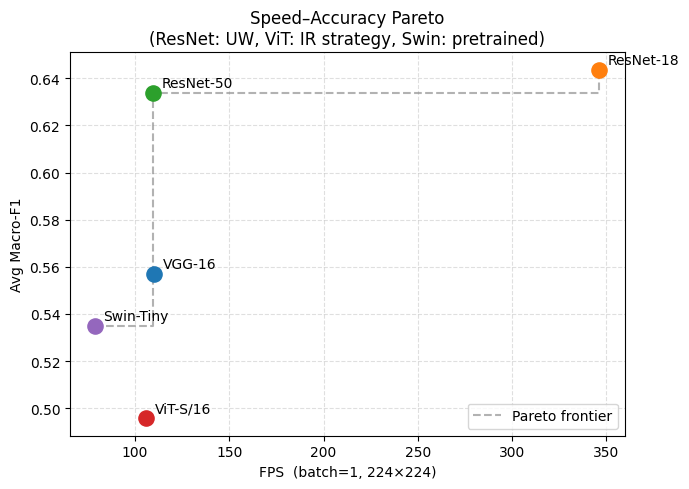

In [8]:
# (모델 팩토리, 체크포인트 경로, 표시 이름)
# 각 백본의 best 체크포인트 사용 (Pareto plot = 아키텍처별 최고 성능 비교)
backbone_cfgs = [
    (VGG16,                 "../checkpoints/level1_vgg16_uw.pth",                           "VGG-16"),
    (resnet18,              "../checkpoints/level1_resnet18_uw.pth",                        "ResNet-18"),
    (resnet50,              "../checkpoints/level1_resnet50_uw.pth",                        "ResNet-50"),
    (vit_small_patch16_224, "../checkpoints/level2_vit_s16-pretrained.pth",                                "ViT-S/16"),
    (SwinTiny,              "../checkpoints/level2_swin_tiny-pretrained.pth",               "Swin-Tiny"),
]

fps_rows   = []
pareto_pts = []  # (name, fps, avg_mf1)

for fn, ckpt_path, name in backbone_cfgs:
    m = fn().to(device)

    # --- FPS 측정 (warm-up 20회, 측정 200회) ---
    m.eval()
    fps = measure_fps(m, device, batch_size=1, n_warmup=20, n_iter=200)

    # --- Avg-MF1: 체크포인트가 있을 때만 계산 ---
    avg_mf1 = float("nan")
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        m.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
        preds, _, tgts, _ = collect_predictions(m, val_loader, device)
        avg_mf1 = average_macro_f1(preds, tgts)

    print(f"{name:12s}  FPS={fps:7.1f}  Avg-MF1={avg_mf1:.4f}")
    fps_rows.append([name, round(fps, 2), round(avg_mf1, 4) if not np.isnan(avg_mf1) else "N/A"])
    pareto_pts.append((name, fps, avg_mf1))

logger.log_table("analysis/fps_mf1", ["backbone", "FPS", "Avg-MF1"], fps_rows)

# --- FPS (x축) vs Avg-MF1 (y축) Pareto plot ---
fig, ax = plt.subplots(figsize=(7, 5))

valid = [(n, f, m) for n, f, m in pareto_pts if not np.isnan(m)]
for name, fps, mf1 in valid:
    ax.scatter(fps, mf1, s=120, zorder=3)
    ax.annotate(name, (fps, mf1), textcoords="offset points", xytext=(6, 4), fontsize=10)

# Pareto frontier (우상단 방향)
if valid:
    sorted_pts = sorted(valid, key=lambda t: t[1])
    frontier, best_mf1 = [], -1.0
    for n, fps, mf1 in sorted_pts:
        if mf1 > best_mf1:
            frontier.append((fps, mf1))
            best_mf1 = mf1
    if len(frontier) > 1:
        fx, fy = zip(*frontier)
        ax.step(fx, fy, where="post", linestyle="--", color="gray", alpha=0.6, label="Pareto frontier")
        ax.legend()

ax.set_xlabel("FPS  (batch=1, 224×224)")
ax.set_ylabel("Avg Macro-F1")
ax.set_title("Speed–Accuracy Pareto\n(ResNet: UW, ViT/Swin: ImageNet pretrained)")
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()
logger.log_image("analysis/pareto", fig)

In [9]:
logger.finish()